<a href="https://colab.research.google.com/github/wajd-mq/wajd-mq/blob/main/DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")

print(path)

100%|██████████| 142k/142k [00:00<00:00, 36.1MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/janiobachmann/bank-marketing-dataset/versions/1


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
import os

print(os.listdir(path))

['bank.csv']


In [ ]:
import pandas as pd
import os

file_path = os.path.join(path, "bank.csv")

df = pd.read_csv(file_path, sep=";")

df.head()

,"age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit"
0,"59,admin.,married,secondary,no,2343,yes,no,unk..."
1,"56,admin.,married,secondary,no,45,no,no,unknow..."
2,"41,technician,married,secondary,no,1270,yes,no..."
3,"55,services,married,secondary,no,2476,yes,no,u..."
4,"54,admin.,married,tertiary,no,184,no,no,unknow..."


In [ ]:
df.shape

(11162, 1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 1 columns):
 #   Column                                                                                                                      Non-Null Count  Dtype 
---  ------                                                                                                                      --------------  ----- 
 0   age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit  11162 non-null  object
dtypes: object(1)
memory usage: 87.3+ KB


In [ ]:
df = pd.read_csv(file_path, sep=",")

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [ ]:
df["deposit"].value_counts()

,count
deposit,
no,5873
yes,5289


In [ ]:
X = df.drop("deposit", axis=1)

y = df["deposit"]

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [ ]:
print(y[:10])

[1 1 1 1 1 1 1 1 1 1]


In [ ]:
categorical_cols = X.select_dtypes(include="object").columns

print(categorical_cols)

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')


In [ ]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    dtype=int
)

In [ ]:
X.shape

(11162, 51)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(8929, 51)
(2233, 51)


In [ ]:
# ============================================
# Bank Marketing - Sequential Neural Network
# ============================================

# Import Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ============================
# 1. Build Sequential Model
# ============================

model = Sequential()

# Input Layer + First Hidden Layer
model.add(Dense(
    64,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

# Dropout to reduce overfitting
model.add(Dropout(0.3))


# Second Hidden Layer
model.add(Dense(
    32,
    activation='relu'
))

model.add(Dropout(0.2))


# Output Layer (Binary Classification)
model.add(Dense(
    1,
    activation='sigmoid'
))


# ============================
# 2. Compile Model
# ============================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# Display Model Architecture
model.summary()



# ============================
# 3. Early Stopping
# ============================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)



# ============================
# 4. Train Model
# ============================

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)



# ============================
# 5. Evaluate Model
# ============================

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)


print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)



# ============================
# 6. Predictions
# ============================

y_pred_prob = model.predict(X_test)

# Convert probability to class
y_pred = (y_pred_prob > 0.5).astype(int)


# ============================
# 7. Metrics
# ============================

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred
))


print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,441 (21.25 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7158 - loss: 0.5560 - val_accuracy: 0.7962 - val_loss: 0.4455
Epoch 2/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7969 - loss: 0.4528 - val_accuracy: 0.8152 - val_loss: 0.4034
Epoch 3/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8194 - loss: 0.4125 - val_accuracy: 0.8298 - val_loss: 0.3877
Epoch 4/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8316 - loss: 0.3889 - val_accuracy: 0.8326 - val_loss: 0.3800
Epoch 5/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8327 - loss: 0.3897 - val_accuracy: 0.8354 - val_loss: 0.3769
Epoch 6/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8426 - loss: 0.3752 - val_accuracy: 0.8376 - val_loss: 0.3717
Epoch 7/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8449 - loss: 0.3661 - val_accuracy: 0.8415 - val_loss: 0.3699
Epoch 8/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8473 - loss: 0.3643 - val_accu

In [ ]:
# ============================================
# Bank Marketing - Functional API Model
# ============================================

import tensorflow as tf

from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix


# ============================
# 1. Define Input Layer
# ============================

inputs = Input(
    shape=(X_train.shape[1],)
)


# ============================
# 2. Hidden Layers
# ============================

x = Dense(
    64,
    activation='relu'
)(inputs)

x = Dropout(0.3)(x)


x = Dense(
    32,
    activation='relu'
)(x)

x = Dropout(0.2)(x)


# ============================
# 3. Output Layer
# ============================

outputs = Dense(
    1,
    activation='sigmoid'
)(x)



# ============================
# 4. Create Model
# ============================

model_functional = Model(
    inputs=inputs,
    outputs=outputs
)


# Model Summary
model_functional.summary()



# ============================
# 5. Compile
# ============================

model_functional.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



# ============================
# 6. Early Stopping
# ============================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)



# ============================
# 7. Train
# ============================

history_functional = model_functional.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)



# ============================
# 8. Evaluation
# ============================

test_loss, test_accuracy = model_functional.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)



# ============================
# 9. Prediction
# ============================

y_pred_prob = model_functional.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)



# ============================
# 10. Metrics
# ============================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)


print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 51)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,441 (21.25 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7061 - loss: 0.5605 - val_accuracy: 0.8068 - val_loss: 0.4275
Epoch 2/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8025 - loss: 0.4420 - val_accuracy: 0.8242 - val_loss: 0.4015
Epoch 3/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8244 - loss: 0.4109 - val_accuracy: 0.8292 - val_loss: 0.3826
Epoch 4/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8298 - loss: 0.3967 - val_accuracy: 0.8359 - val_loss: 0.3784
Epoch 5/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8391 - loss: 0.3820 - val_accuracy: 0.8399 - val_loss: 0.3727
Epoch 6/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8432 - loss: 0.3733 - val_accuracy: 0.8449 - val_loss: 0.3689
Epoch 7/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8487 - loss: 0.3682 - val_accuracy: 0.8455 - val_loss: 0.3711
Epoch 8/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8466 - loss: 0.3585 - val_acc

In [ ]:
# ============================================
# Bank Marketing - Optimized Sequential Model
# ============================================

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix


# ============================================
# Calculate Class Weights
# ============================================

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))


# ============================================
# Build Model
# ============================================

model_seq = Sequential()


model_seq.add(
    Dense(
        128,
        input_shape=(X_train.shape[1],)
    )
)

model_seq.add(BatchNormalization())
model_seq.add(tf.keras.layers.Activation('relu'))
model_seq.add(Dropout(0.3))


model_seq.add(
    Dense(64)
)

model_seq.add(BatchNormalization())
model_seq.add(tf.keras.layers.Activation('relu'))
model_seq.add(Dropout(0.3))


model_seq.add(
    Dense(32)
)

model_seq.add(BatchNormalization())
model_seq.add(tf.keras.layers.Activation('relu'))


# Output
model_seq.add(
    Dense(
        1,
        activation='sigmoid'
    )
)


# ============================================
# Compile
# ============================================

optimizer = Adam(
    learning_rate=0.0005
)


model_seq.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)


model_seq.summary()



# ============================================
# Callbacks
# ============================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)


reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6
)



# ============================================
# Train
# ============================================

history_seq = model_seq.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=1
)



# ============================================
# Evaluation
# ============================================

loss, acc = model_seq.evaluate(
    X_test,
    y_test
)

print("Test Loss:", loss)
print("Test Accuracy:", acc)


y_pred = (model_seq.predict(X_test) > 0.5).astype(int)


print(
    classification_report(
        y_test,
        y_pred
    )
)


print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,921 (70.00 KB)

 Trainable params: 17,473 (68.25 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6637 - loss: 0.6067 - val_accuracy: 0.7878 - val_loss: 0.4912 - learning_rate: 5.0000e-04
Epoch 2/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7656 - loss: 0.4975 - val_accuracy: 0.8180 - val_loss: 0.4173 - learning_rate: 5.0000e-04
Epoch 3/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8046 - loss: 0.4397 - val_accuracy: 0.8231 - val_loss: 0.3915 - learning_rate: 5.0000e-04
Epoch 4/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8156 - loss: 0.4215 - val_accuracy: 0.8337 - val_loss: 0.3804 - learning_rate: 5.0000e-04
Epoch 5/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8232 - loss: 0.4065 - val_accuracy: 0.8393 - val_loss: 0.3737 - learning_rate: 5.0000e-04
Epoch 6/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8275 - loss: 0.3939 - val_accuracy: 0.8320 - val_loss: 0.3735 - learning_rate: 5.0000e-04
Epoch 7/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - ac

In [ ]:
# ============================================
# Bank Marketing - Optimized Functional API
# ============================================

import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    Activation
)

from tensorflow.keras.models import Model

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix



# ============================================
# Input Layer
# ============================================

inputs = Input(
    shape=(X_train.shape[1],)
)



# ============================================
# Hidden Layers
# ============================================

x = Dense(128)(inputs)

x = BatchNormalization()(x)

x = Activation('relu')(x)

x = Dropout(0.3)(x)



x = Dense(64)(x)

x = BatchNormalization()(x)

x = Activation('relu')(x)

x = Dropout(0.3)(x)



x = Dense(32)(x)

x = BatchNormalization()(x)

x = Activation('relu')(x)



# Output

outputs = Dense(
    1,
    activation='sigmoid'
)(x)



# Create Model

model_func = Model(
    inputs,
    outputs
)


model_func.summary()



# ============================================
# Compile
# ============================================

model_func.compile(
    optimizer=Adam(
        learning_rate=0.0005
    ),
    loss='binary_crossentropy',
    metrics=['accuracy']
)



# ============================================
# Callbacks
# ============================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)


reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6
)



# ============================================
# Train
# ============================================

history_func = model_func.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=1
)



# ============================================
# Evaluation
# ============================================

loss, acc = model_func.evaluate(
    X_test,
    y_test
)

print("Test Loss:", loss)
print("Test Accuracy:", acc)



y_pred = (
    model_func.predict(X_test) > 0.5
).astype(int)



print(
    classification_report(
        y_test,
        y_pred
    )
)


print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 51)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,921 (70.00 KB)

 Trainable params: 17,473 (68.25 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6643 - loss: 0.6098 - val_accuracy: 0.7945 - val_loss: 0.4829 - learning_rate: 5.0000e-04
Epoch 2/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7585 - loss: 0.4984 - val_accuracy: 0.8147 - val_loss: 0.4139 - learning_rate: 5.0000e-04
Epoch 3/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7990 - loss: 0.4521 - val_accuracy: 0.8287 - val_loss: 0.3901 - learning_rate: 5.0000e-04
Epoch 4/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8165 - loss: 0.4238 - val_accuracy: 0.8404 - val_loss: 0.3772 - learning_rate: 5.0000e-04
Epoch 5/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8218 - loss: 0.4082 - val_accuracy: 0.8443 - val_loss: 0.3716 - learning_rate: 5.0000e-04
Epoch 6/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8286 - loss: 0.4010 - val_accuracy: 0.8432 - val_loss: 0.3667 - learning_rate: 5.0000e-04
Epoch 7/200
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc

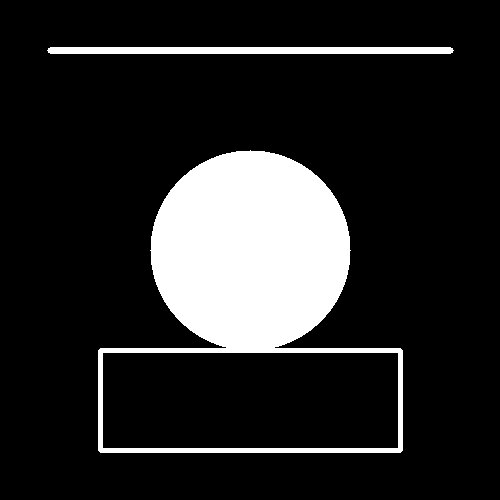

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# إنشاء صورة سوداء (Grayscale)
img = np.zeros((500, 500), dtype=np.uint8)

# رسم خط أبيض
cv2.line(
    img,
    (50, 50),
    (450, 50),
    255,
    5
)

# رسم دائرة بيضاء
cv2.circle(
    img,
    (250, 250),
    100,
    255,
    -1
)

# رسم مستطيل أبيض
cv2.rectangle(
    img,
    (100, 350),
    (400, 450),
    255,
    3
)

# عرض الصورة في Colab
cv2_imshow(img)

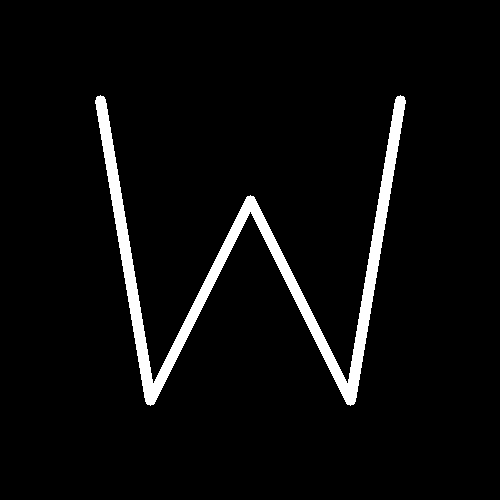

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# إنشاء صورة سوداء
img = np.zeros((500, 500), dtype=np.uint8)

# نقاط حرف W
points = [
    (100, 100),
    (150, 400),
    (250, 200),
    (350, 400),
    (400, 100)
]

# رسم حرف W
for i in range(len(points)-1):
    cv2.line(
        img,
        points[i],
        points[i+1],
        255,   # اللون الأبيض
        10     # سمك الخط
    )

# عرض الصورة
cv2_imshow(img)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2986s 18us/step


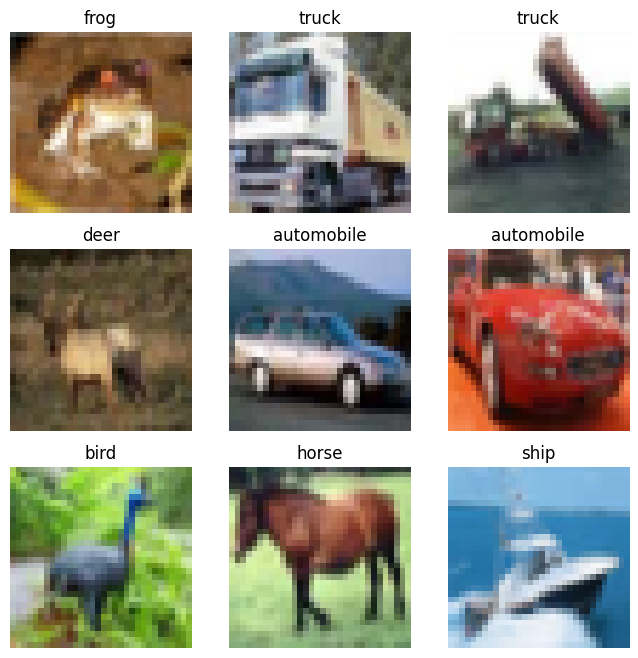

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 552,874 (2.11 MB)

 Trainable params: 551,722 (2.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 336s 528ms/step - accuracy: 0.4314 - loss: 1.6616 - val_accuracy: 0.5630 - val_loss: 1.2355
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 330s 528ms/step - accuracy: 0.6066 - loss: 1.1211 - val_accuracy: 0.6460 - val_loss: 0.9968
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 332s 531ms/step - accuracy: 0.6759 - loss: 0.9270 - val_accuracy: 0.6905 - val_loss: 0.8842
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 382s 532ms/step - accuracy: 0.7181 - loss: 0.8146 - val_accuracy: 0.7405 - val_loss: 0.7432
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 380s 529ms/step - accuracy: 0.7478 - loss: 0.7322 - val_accuracy: 0.7586 - val_loss: 0.6974
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 333s 533ms/step - accuracy: 0.7669 - loss: 0.6744 - val_accuracy: 0.7691 - val_loss: 0.6753
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 336s 538ms/step - accuracy: 0.7883 - loss: 0.6205 - val_accuracy: 0.7042 - val_loss: 0.9337
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 378s 531ms/step - accuracy: 0.7974 -

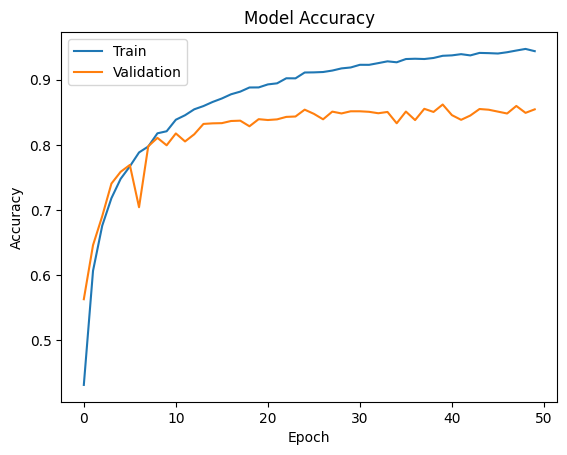

In [ ]:
# ==============================
# CIFAR-10 CNN Classification
# ==============================

# Import Libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


# Load CIFAR-10 Dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()


# Normalize pixels
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0


# Class names
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]


# Display sample images
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()



# ==============================
# CNN Model
# ==============================

model = models.Sequential([

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu',
                  padding='same',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),

    layers.Conv2D(32, (3,3), activation='relu',
                  padding='same'),
    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),


    # Block 2
    layers.Conv2D(64, (3,3), activation='relu',
                  padding='same'),
    layers.BatchNormalization(),

    layers.Conv2D(64, (3,3), activation='relu',
                  padding='same'),
    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),



    # Block 3
    layers.Conv2D(128, (3,3), activation='relu',
                  padding='same'),

    layers.BatchNormalization(),

    layers.Conv2D(128, (3,3), activation='relu',
                  padding='same'),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),



    # Classification
    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.BatchNormalization(),

    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])


# Model Summary
model.summary()



# ==============================
# Compile
# ==============================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



# ==============================
# Training
# ==============================

history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2
)



# ==============================
# Evaluation
# ==============================

test_loss, test_acc = model.evaluate(
    x_test,
    y_test
)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)



# ==============================
# Plot Accuracy
# ==============================

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend([
    'Train',
    'Validation'
])

plt.show()